### Rock Density Data:

- We just got hired by a tunnel boring company which uses X-rays in an attempt to know rock density, ideally this will allow them to switch out boring heads on their equipment before having to mine through the rock!

- They have given us some lab test results of signal strength returned in nHz to their sensors for various rock density types tested. You will notice it has almost a sine wave like relationship, where signal strength oscillates based off the density.

#### 1) Importing Necessary Libraries:

In [31]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.pipeline import Pipeline

import warnings
warnings.filterwarnings('ignore')

#### 2) Loading The Data:

In [2]:
df= pd.read_csv('rock_density_xray.csv')

In [3]:
df.head()

,Rebound Signal Strength nHz,Rock Density kg/m3
0,72.945124,2.456548
1,14.229877,2.601719
2,36.597334,1.967004
3,9.578899,2.300439
4,21.765897,2.452374


In [5]:
df.shape

(300, 2)

- Signal Strength is Feature Variable and Rock Density is Target Variable.

In [6]:
df.describe()

,Rebound Signal Strength nHz,Rock Density kg/m3
count,300.000000,300.000000
mean,49.725766,2.225063
std,28.341792,0.314512
min,0.700227,1.500000
25%,25.685798,1.987830
50%,50.602886,2.268597
75%,74.854294,2.476944
max,98.831658,2.750000


In [7]:
# Renaming Column Names for Simplicity:

df.columns = ['Signal', 'Density']

In [8]:
df.head()

,Signal,Density
0,72.945124,2.456548
1,14.229877,2.601719
2,36.597334,1.967004
3,9.578899,2.300439
4,21.765897,2.452374


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300 entries, 0 to 299
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Signal   300 non-null    float64
 1   Density  300 non-null    float64
dtypes: float64(2)
memory usage: 4.8 KB


- There are No Missing Values in Data.

#### 3) Data Exploration and Transformation:

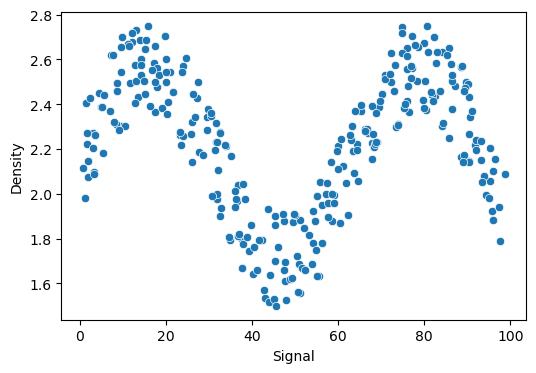

In [10]:
plt.figure(figsize= (6,4))
sns.scatterplot(data= df, x= 'Signal', y= 'Density')
plt.show()

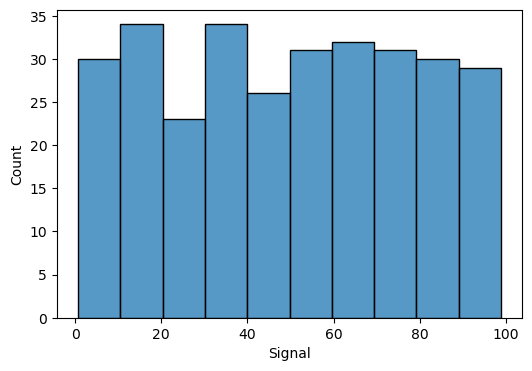

In [11]:
plt.figure(figsize= (6,4))
sns.histplot(data= df, x= 'Signal')
plt.show()

- Signal Strength has mostly Uniform Distribution.
- No need to do any Imputations or Transformations except Scaling.

#### 4) Final Column Transformer:

In [21]:
preprocessor = ColumnTransformer([
    ('scaler', StandardScaler(), ['Signal'])
])

#### 5) Train Test Split:

In [18]:
X = df[['Signal']] # Feature
y = df['Density'] # Target

In [19]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size= 0.2, random_state= 42)

In [20]:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(240, 1)
(60, 1)
(240,)
(60,)


#### 6) Random Forest Regressor Using Grid Search:

In [25]:
model_pipeline = Pipeline([
    ('Preprocessing', preprocessor),
    ('Model', RandomForestRegressor())
])

param_dict = {'Model__n_estimators': [1,5,10,25,50,100,200],
             'Model__bootstrap': [True, False],
             'Model__oob_score': [True, False]}

grid_model = GridSearchCV(estimator= model_pipeline, 
                          param_grid= param_dict, 
                          cv= 10)

In [26]:
# Fitting Grid Model:

grid_model.fit(X_train, y_train)

,estimator,Pipeline(step...Regressor())])
,param_grid,"{'Model__bootstrap': [True, False], 'Model__n_estimators': [1, 5, ...], 'Model__oob_score': [True, False]}"
,scoring,None
,n_jobs,None
,refit,True
,cv,10
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,transformers,"[('scaler', ...)]"


In [29]:
# Best Parameters According to Grid Search:

print(grid_model.best_params_)
print(grid_model.best_estimator_)
print(grid_model.best_score_)

{'Model__bootstrap': True, 'Model__n_estimators': 50, 'Model__oob_score': True}
Pipeline(steps=[('Preprocessing',
                 ColumnTransformer(transformers=[('scaler', StandardScaler(),
                                                  ['Signal'])])),
                ('Model',
                 RandomForestRegressor(n_estimators=50, oob_score=True))])
0.686546095165057


In [37]:
# Grid Seach Results:

pd.DataFrame(grid_model.cv_results_)[['params', 'mean_test_score', 'rank_test_score']].sort_values(by= 'rank_test_score', ascending= True)

,params,mean_test_score,rank_test_score
8,"{'Model__bootstrap': True, 'Model__n_estimator...",0.686546,1
10,"{'Model__bootstrap': True, 'Model__n_estimator...",0.685423,2
13,"{'Model__bootstrap': True, 'Model__n_estimator...",0.683335,3
4,"{'Model__bootstrap': True, 'Model__n_estimator...",0.682709,4
2,"{'Model__bootstrap': True, 'Model__n_estimator...",0.681555,5
12,"{'Model__bootstrap': True, 'Model__n_estimator...",0.681060,6
11,"{'Model__bootstrap': True, 'Model__n_estimator...",0.680099,7
9,"{'Model__bootstrap': True, 'Model__n_estimator...",0.678385,8
5,"{'Model__bootstrap': True, 'Model__n_estimator...",0.678196,9
7,"{'Model__bootstrap': True, 'Model__n_estimator...",0.677680,10


In [32]:
# Predictions Usnig Best Estimator from Grid Model:

y_pred = grid_model.predict(X_test)

In [33]:
# Model Evaluation:

print(f'R2-Score: {r2_score(y_test, y_pred)}')
print(f'MAE: {mean_absolute_error(y_test, y_pred)}')
print(f'RMSE: {np.sqrt(mean_squared_error(y_test, y_pred))}')

R2-Score: 0.7683246835703439
MAE: 0.12892002117831458
RMSE: 0.15574374179109338
